In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
# Set the random seed for reproducibility
np.random.seed(42)

In [7]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [8]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [9]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


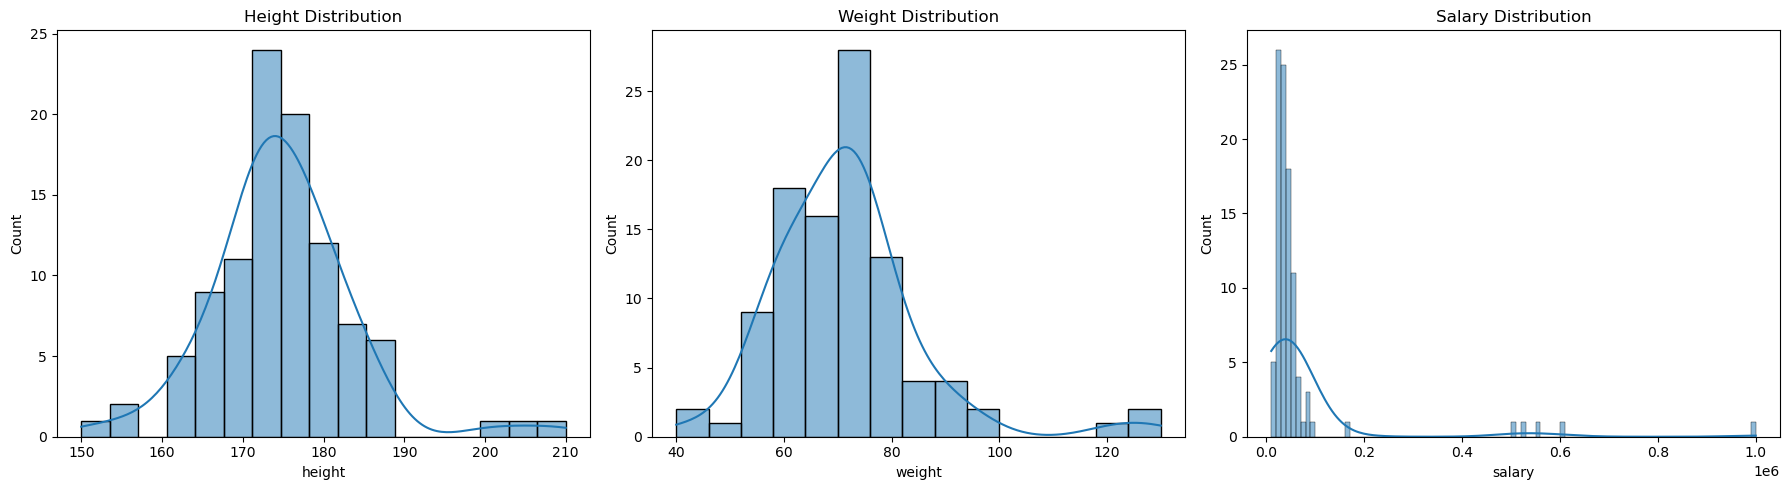

In [10]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

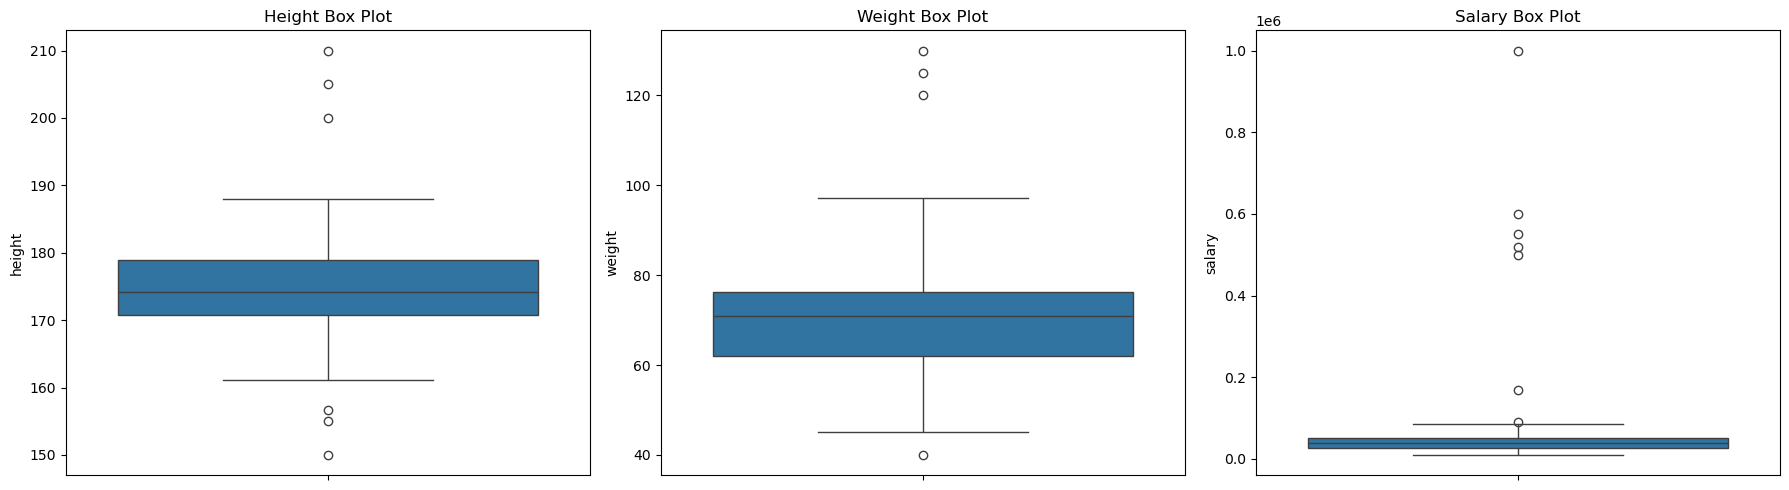

In [11]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

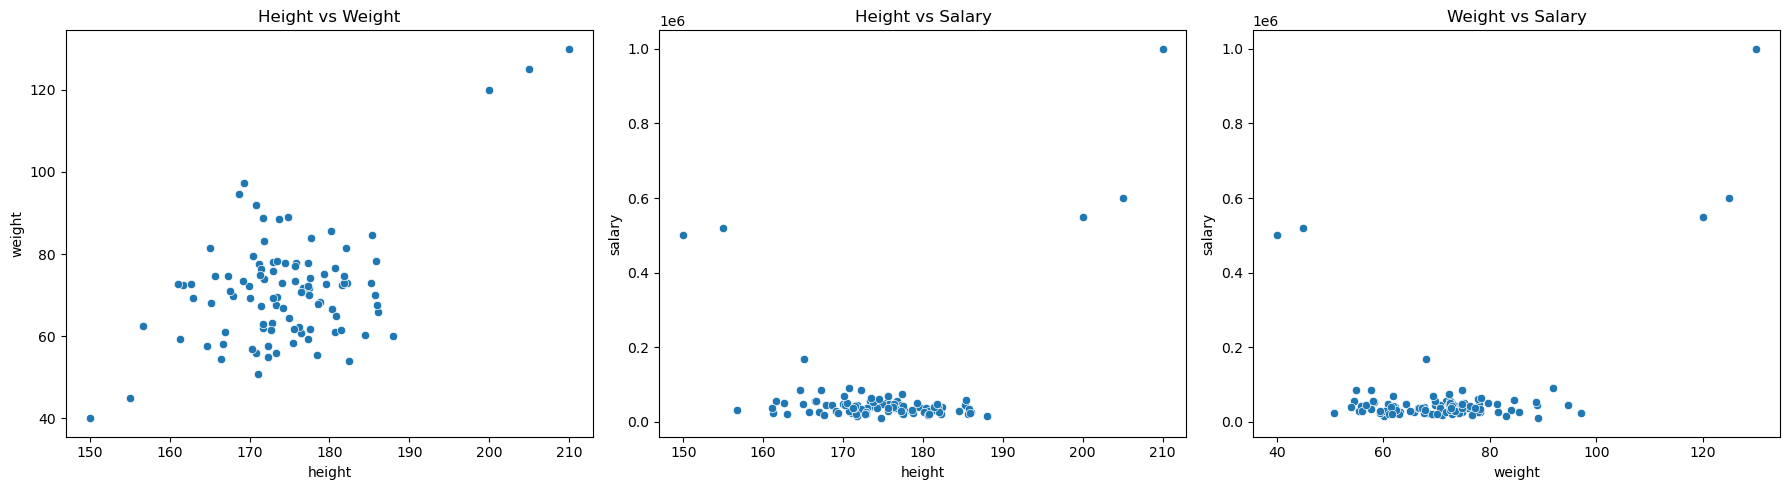

In [12]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [13]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [14]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [15]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [16]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


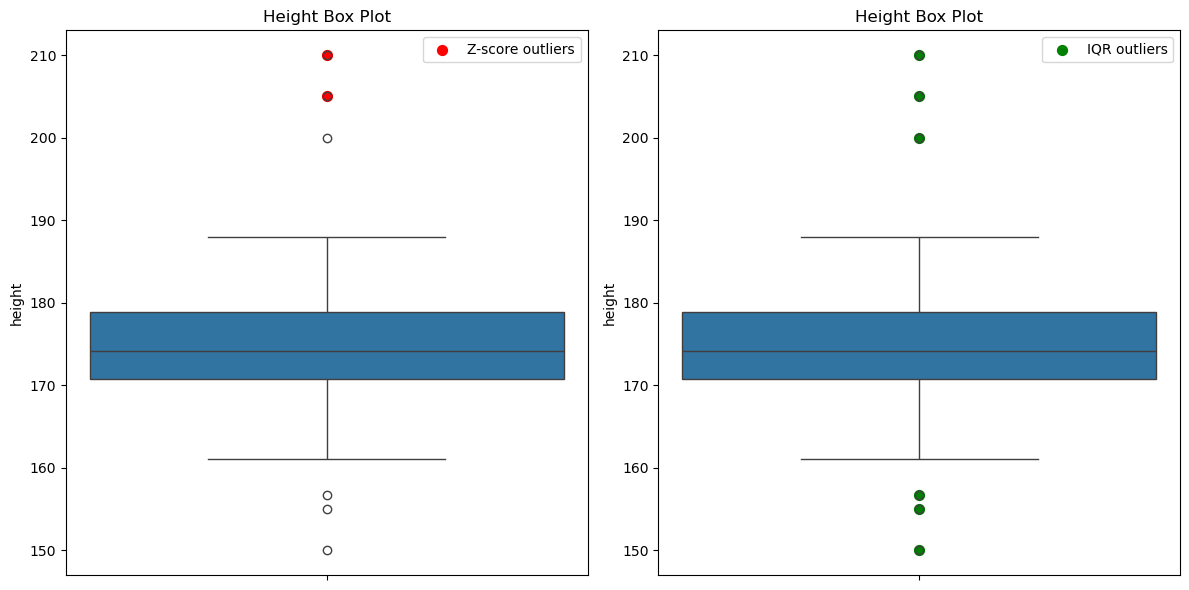

In [17]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [19]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [20]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [21]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


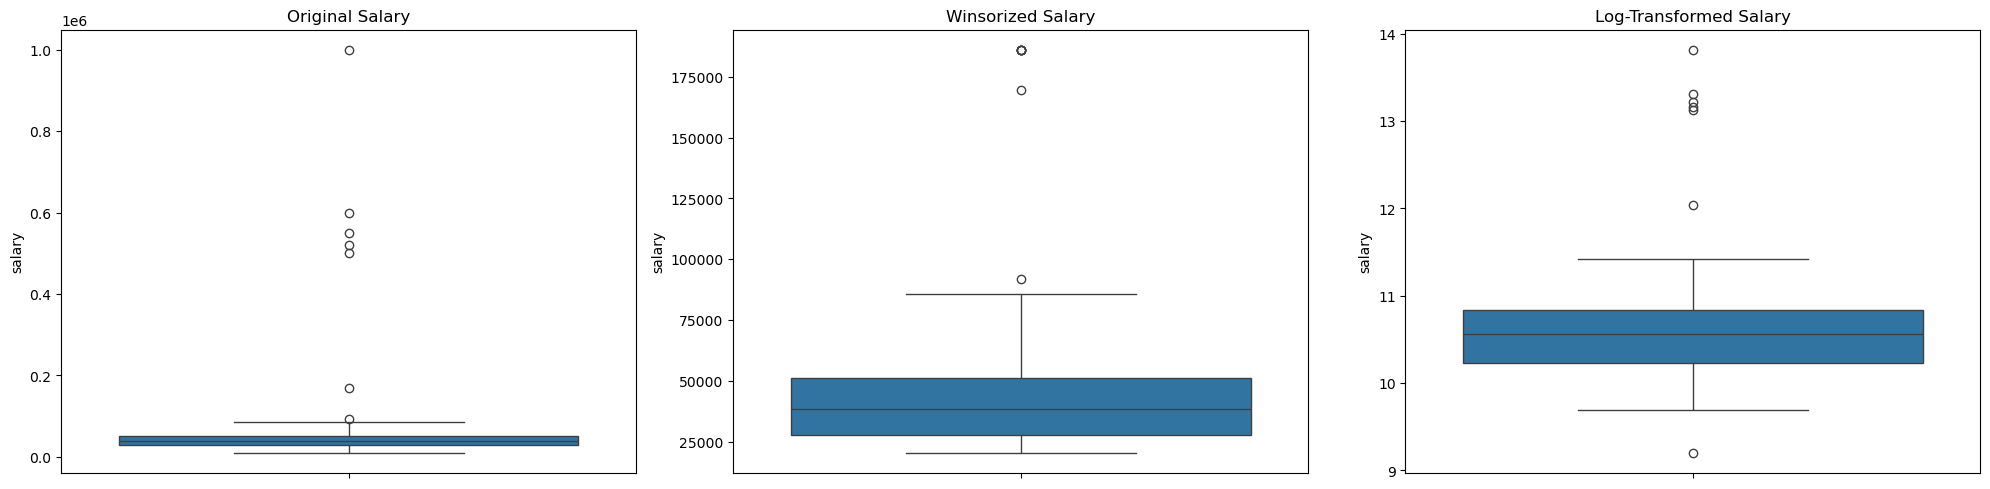

In [22]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [23]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


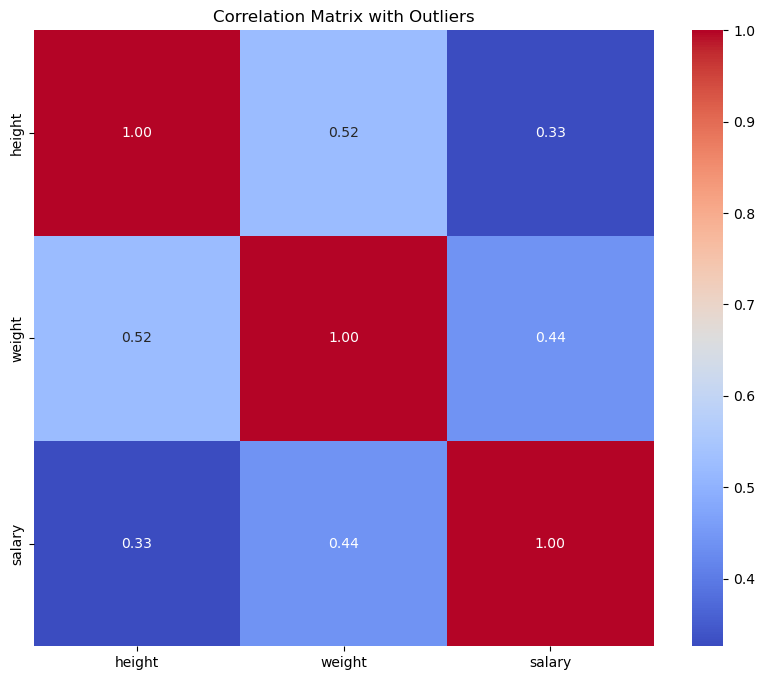

In [24]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


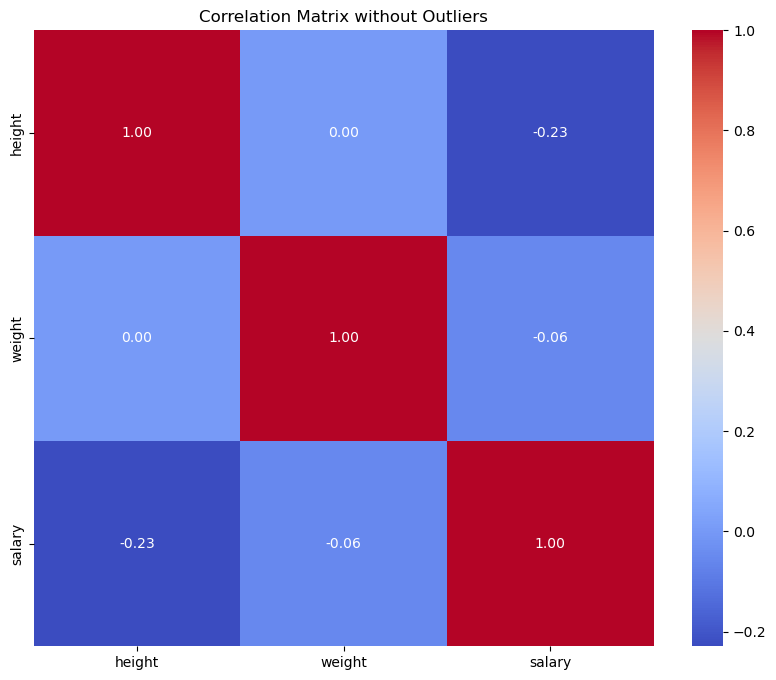

In [25]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()

In [26]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [27]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [28]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [29]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

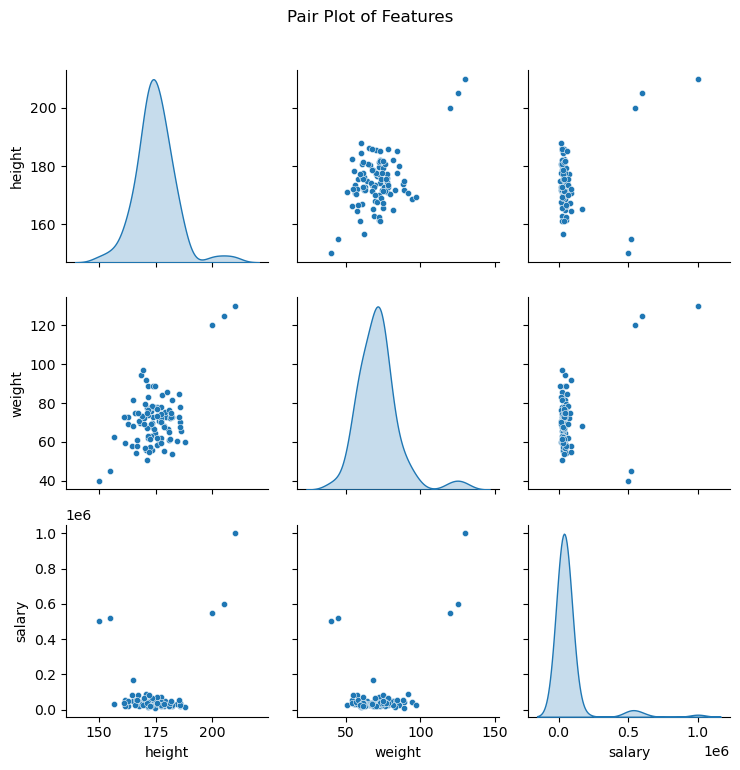

In [30]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\ZEENAT MUSTAFA\AppData\Local\Temp\ipykernel_4356\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


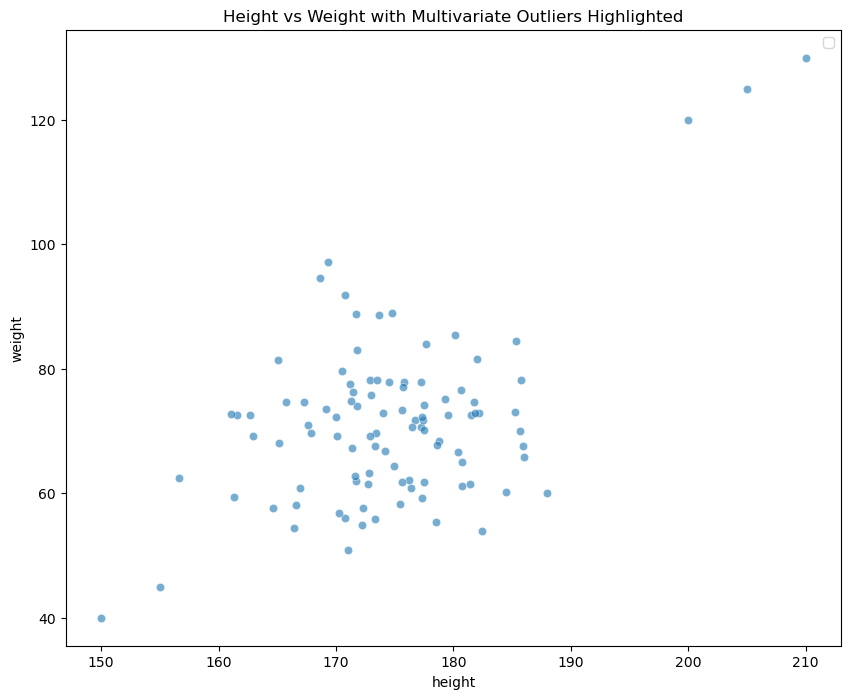

In [31]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


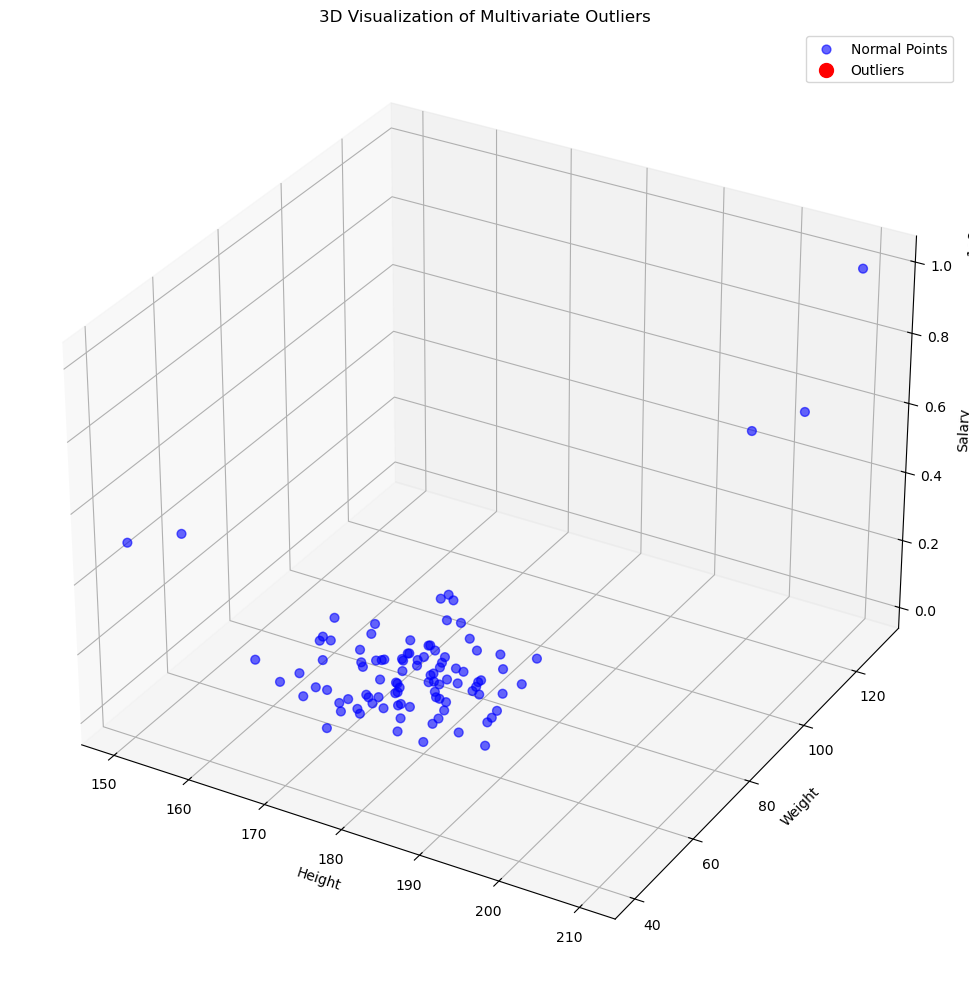

In [32]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


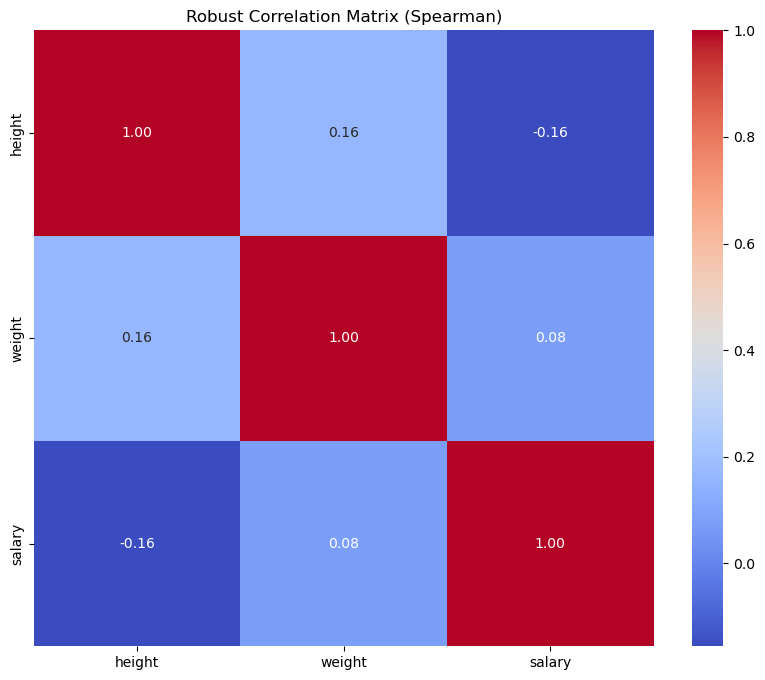

In [33]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [34]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [35]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [36]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

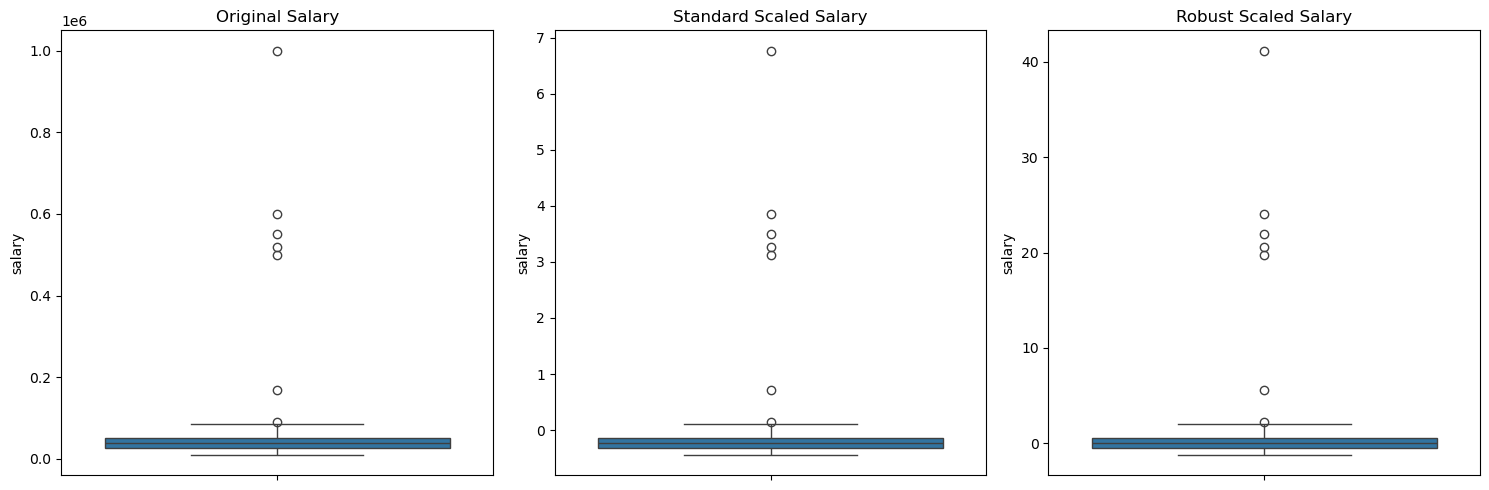

In [37]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [38]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [39]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

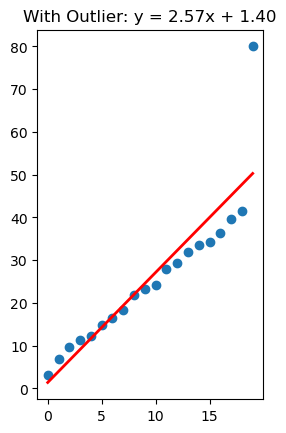

In [40]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


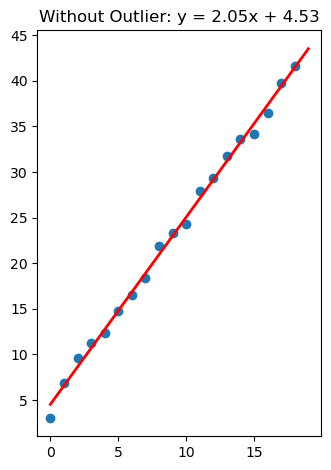

In [41]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [42]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [43]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


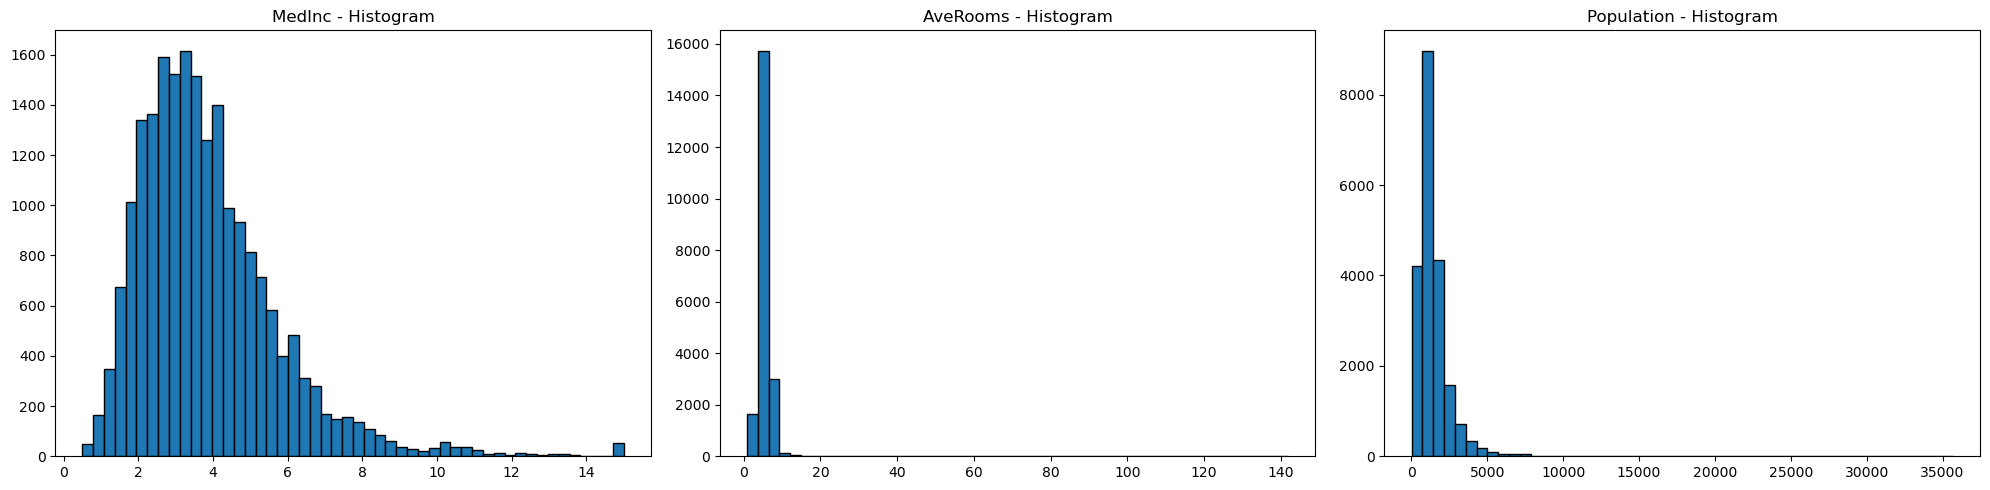

In [64]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots

features_to_check = ['MedInc', 'AveRooms', 'Population']

# Histograms
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.hist(df.MedInc, bins=50, edgecolor='black')
plt.title("MedInc - Histogram")

plt.subplot(1, 3, 2)
plt.hist(df.AveRooms, bins=50, edgecolor='black')
plt.title("AveRooms - Histogram")

plt.subplot(1, 3, 3)
plt.hist(df.Population, bins=50, edgecolor='black')
plt.title("Population - Histogram")

plt.tight_layout()
plt.show()

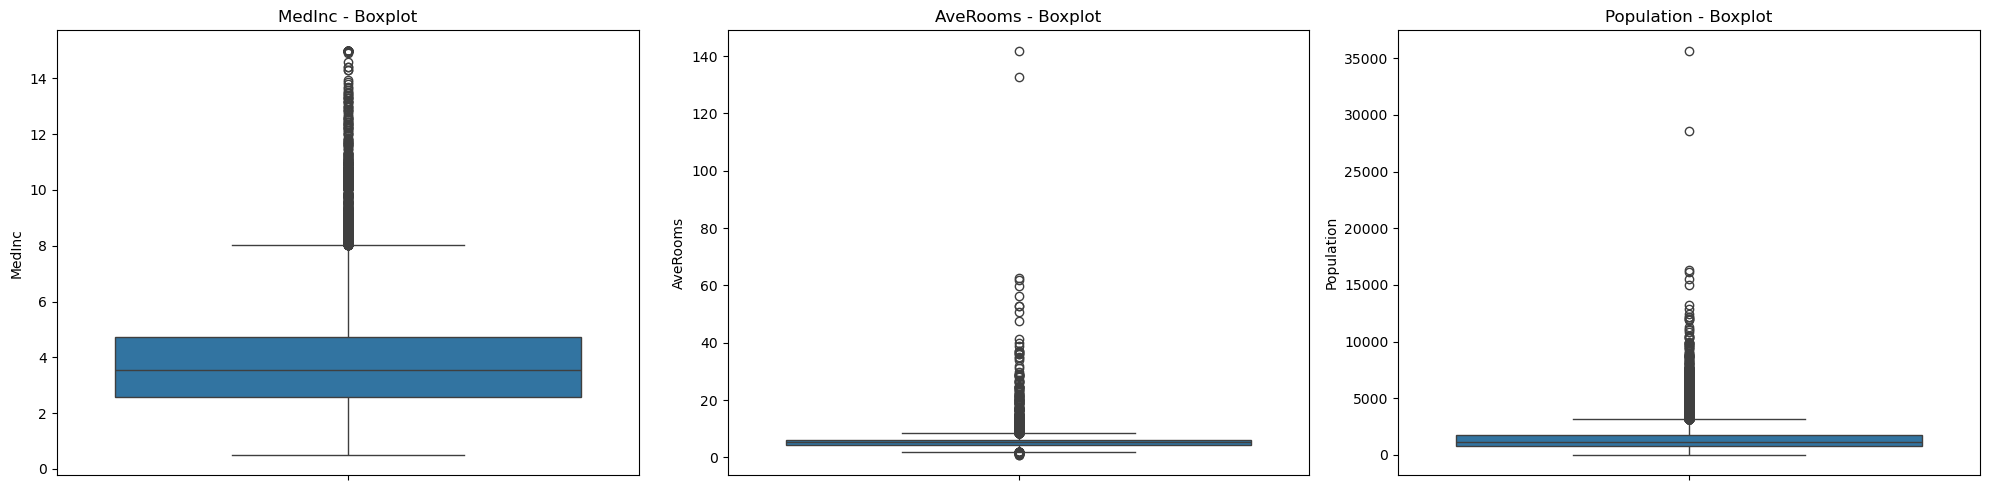

In [52]:
# Boxplots
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['MedInc'])
plt.title('MedInc - Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['AveRooms'])
plt.title('AveRooms - Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Population'])
plt.title('Population - Boxplot')

plt.tight_layout()
plt.show()

In [ ]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the MedHouseVal feature
# MedHouseVal: % lower status of the population

feature_name = 'MedHouseVal'
feature_data = df[feature_name]

# Z-score outliers
z_outliers = detect_outliers_zscore(feature_data)

# IQR outliers
iqr_outliers = detect_outliers_iqr(feature_data)

print(f"{feature_name} outliers (Z-score): {len(z_outliers)} found")
print(f"{feature_name} outliers (IQR): {len(iqr_outliers)} found")

print(f"\nZ-score outlier indices (first 10): {z_outliers[:10]}")
print(f"IQR outlier indices (first 10): {iqr_outliers[:10]}")

print(f"\nZ-score outlier %: {len(z_outliers) / len(feature_data) * 100:.2f}%")
print(f"IQR outlier %: {len(iqr_outliers) / len(feature_data) * 100:.2f}%")

MedHouseVal outliers (Z-score): 0 found
MedHouseVal outliers (IQR): 1071 found

Z-score outlier indices (first 10): []
IQR outlier indices (first 10): [ 89 140 459 489 493 494 509 510 511 512]

Z-score outlier %: 0.00%
IQR outlier %: 5.19%


In [66]:
(df['MedHouseVal'] == df['MedHouseVal'].max()).sum()

np.int64(965)

In [67]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_forest.fit_predict(df)

n_outliers = (outlier_mask == -1).sum()
n_inliers = (outlier_mask == 1).sum()

print(f"Total points: {len(df)}")
print(f"Outliers detected: {n_outliers}")
print(f"Inliers detected: {n_inliers}")
print(f"Outlier percentage: {n_outliers / len(df) * 100:.2f}%")

iso_outlier_indices = np.where(outlier_mask == -1)[0]
print(f"\nOutlier indices (first 10): {iso_outlier_indices[:10]}")

Total points: 20640
Outliers detected: 1032
Inliers detected: 19608
Outlier percentage: 5.00%

Outlier indices (first 10): [ 59  63  73  89  91  92 131 155 192 270]


In [ ]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'medinc' to predict 'medhousevalue'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

# Your implementation here


In [68]:
def build_and_evaluate_model(data, label):
    """Fit a linear regression of MedHouseVal ~ MedInc and print results"""
    X_feat = data[['MedInc']]   # 2D input required by sklearn
    y_target = data['MedHouseVal']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_feat, y_target, test_size=0.2, random_state=42
    )
    
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"--- {label} ---")
    print(f"Rows used: {len(data)}")
    print(f"Coefficient (slope): {model.coef_[0]:.4f}")
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"R² score: {r2:.4f}")
    print(f"MSE: {mse:.4f}\n")
    
    return model, r2

# (a) Version with ALL data
model_all, r2_all = build_and_evaluate_model(df, "All Data")

--- All Data ---
Rows used: 20640
Coefficient (slope): 0.4193
Intercept: 0.4446
R² score: 0.4589
MSE: 0.7091



In [69]:
# (b) Version after removing Z-score outliers
z_outliers_medinc = detect_outliers_zscore(df['MedInc'])
df_no_z_outliers = df.drop(index=df.index[z_outliers_medinc]).reset_index(drop=True)
model_z, r2_z = build_and_evaluate_model(df_no_z_outliers, "Z-score Outliers Removed")

--- Z-score Outliers Removed ---
Rows used: 20295
Coefficient (slope): 0.4505
Intercept: 0.3340
R² score: 0.4313
MSE: 0.7069



In [70]:
# (c) Version after removing Isolation Forest outliers
df_no_iso_outliers = df.drop(index=df.index[iso_outlier_indices]).reset_index(drop=True)
model_iso, r2_iso = build_and_evaluate_model(df_no_iso_outliers, "Isolation Forest Outliers Removed")

--- Isolation Forest Outliers Removed ---
Rows used: 19608
Coefficient (slope): 0.4533
Intercept: 0.3261
R² score: 0.4420
MSE: 0.6639



In [74]:
# Summary comparison
print("Summary")
print(f"{'Version':<35}{'R²':>10}{'Coefficient':>15}")
print(f"{'All Data':<35}{r2_all:>10.4f}{model_all.coef_[0]:>15.4f}")
print(f"{'Z-score Removed':<35}{r2_z:>10.4f}{model_z.coef_[0]:>15.4f}")
print(f"{'Isolation Forest Removed':<35}{r2_iso:>10.4f}{model_iso.coef_[0]:>15.4f}")

Summary
Version                                    R²    Coefficient
All Data                               0.4589         0.4193
Z-score Removed                        0.4313         0.4505
Isolation Forest Removed               0.4420         0.4533


Z-score flagged: 133
IQR flagged: 511
Consensus (both methods agree): 133


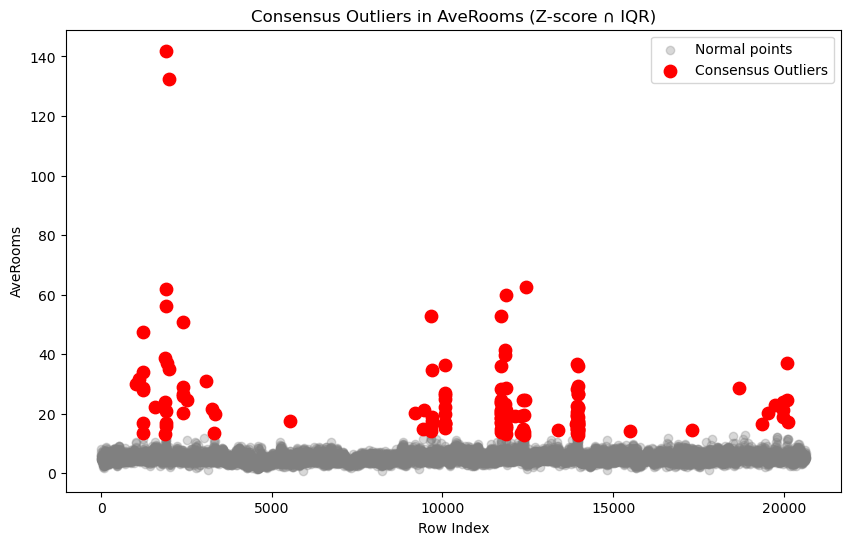

In [77]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

def consensus_outlier_detection(data, column_name):
    """
    Detect outliers using both Z-score and IQR methods.
    Returns only the 'consensus' outliers - flagged by BOTH methods.
    """
    feature = data[column_name]
    
    # Method 1: Z-score
    z_outliers = detect_outliers_zscore(feature)
    
    # Method 2: IQR
    iqr_outliers = detect_outliers_iqr(feature)
    
    # Consensus = outliers found by BOTH methods
    consensus_outliers = np.intersect1d(z_outliers, iqr_outliers)
    
    print(f"Z-score flagged: {len(z_outliers)}")
    print(f"IQR flagged: {len(iqr_outliers)}")
    print(f"Consensus (both methods agree): {len(consensus_outliers)}")
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(feature)), feature, alpha=0.3, color='gray', label='Normal points')
    plt.scatter(consensus_outliers, feature.iloc[consensus_outliers], 
                color='red', s=80, label='Consensus Outliers')
    plt.xlabel('Row Index')
    plt.ylabel(column_name)
    plt.title(f'Consensus Outliers in {column_name} (Z-score ∩ IQR)')
    plt.legend()
    plt.show()
    
    return consensus_outliers


consensus_result = consensus_outlier_detection(df, 'AveRooms')

Text(0.5, 1.0, 'Original AveRooms')

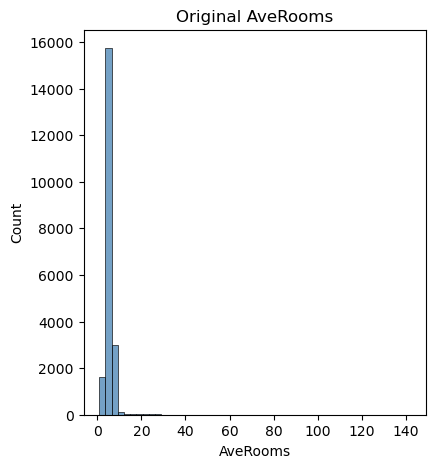

In [82]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['AveRooms'], bins=50, color='steelblue')
plt.title('Original AveRooms')

Text(0.5, 1.0, 'Log-Transformed AveRooms')

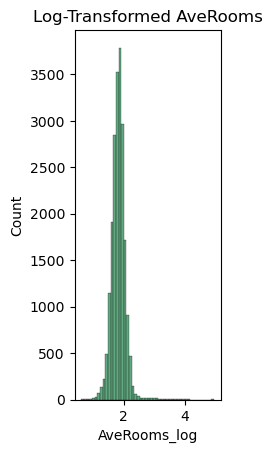

In [83]:
# Log transformation
df['AveRooms_log'] = np.log1p(df['AveRooms'])

plt.subplot(1, 3, 2)
sns.histplot(df['AveRooms_log'], bins=50, color='seagreen')
plt.title('Log-Transformed AveRooms')

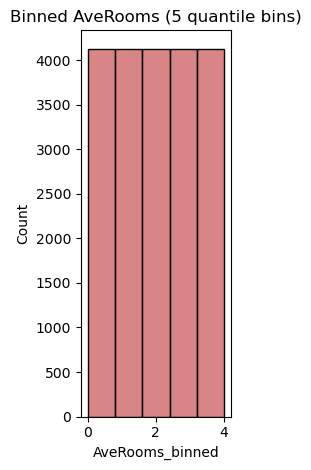

In [84]:
# Binning/discretization
df['AveRooms_binned'] = pd.qcut(df['AveRooms'], q=5, labels=False, duplicates='drop')

plt.subplot(1, 3, 3)
sns.histplot(df['AveRooms_binned'], bins=5, color='indianred')
plt.title('Binned AveRooms (5 quantile bins)')

plt.tight_layout()
plt.show()

In [81]:
# Ratio/interaction feature: rooms per person (more robust, meaningful ratio)
df['Rooms_per_Person'] = df['AveRooms'] / df['AveOccup']

print("Original AveRooms - skew:", stats.skew(df['AveRooms']))
print("Log AveRooms - skew:", stats.skew(df['AveRooms_log']))
print("Rooms per Person - skew:", stats.skew(df['Rooms_per_Person']))

Original AveRooms - skew: 20.69636472075092
Log AveRooms - skew: 1.390660147408497
Rooms per Person - skew: 17.77384164575733


Multivariate outliers found: 20
Indices (first 10): [1102 1240 1872 1912 1913 1914 1979 2395 3086 3364]


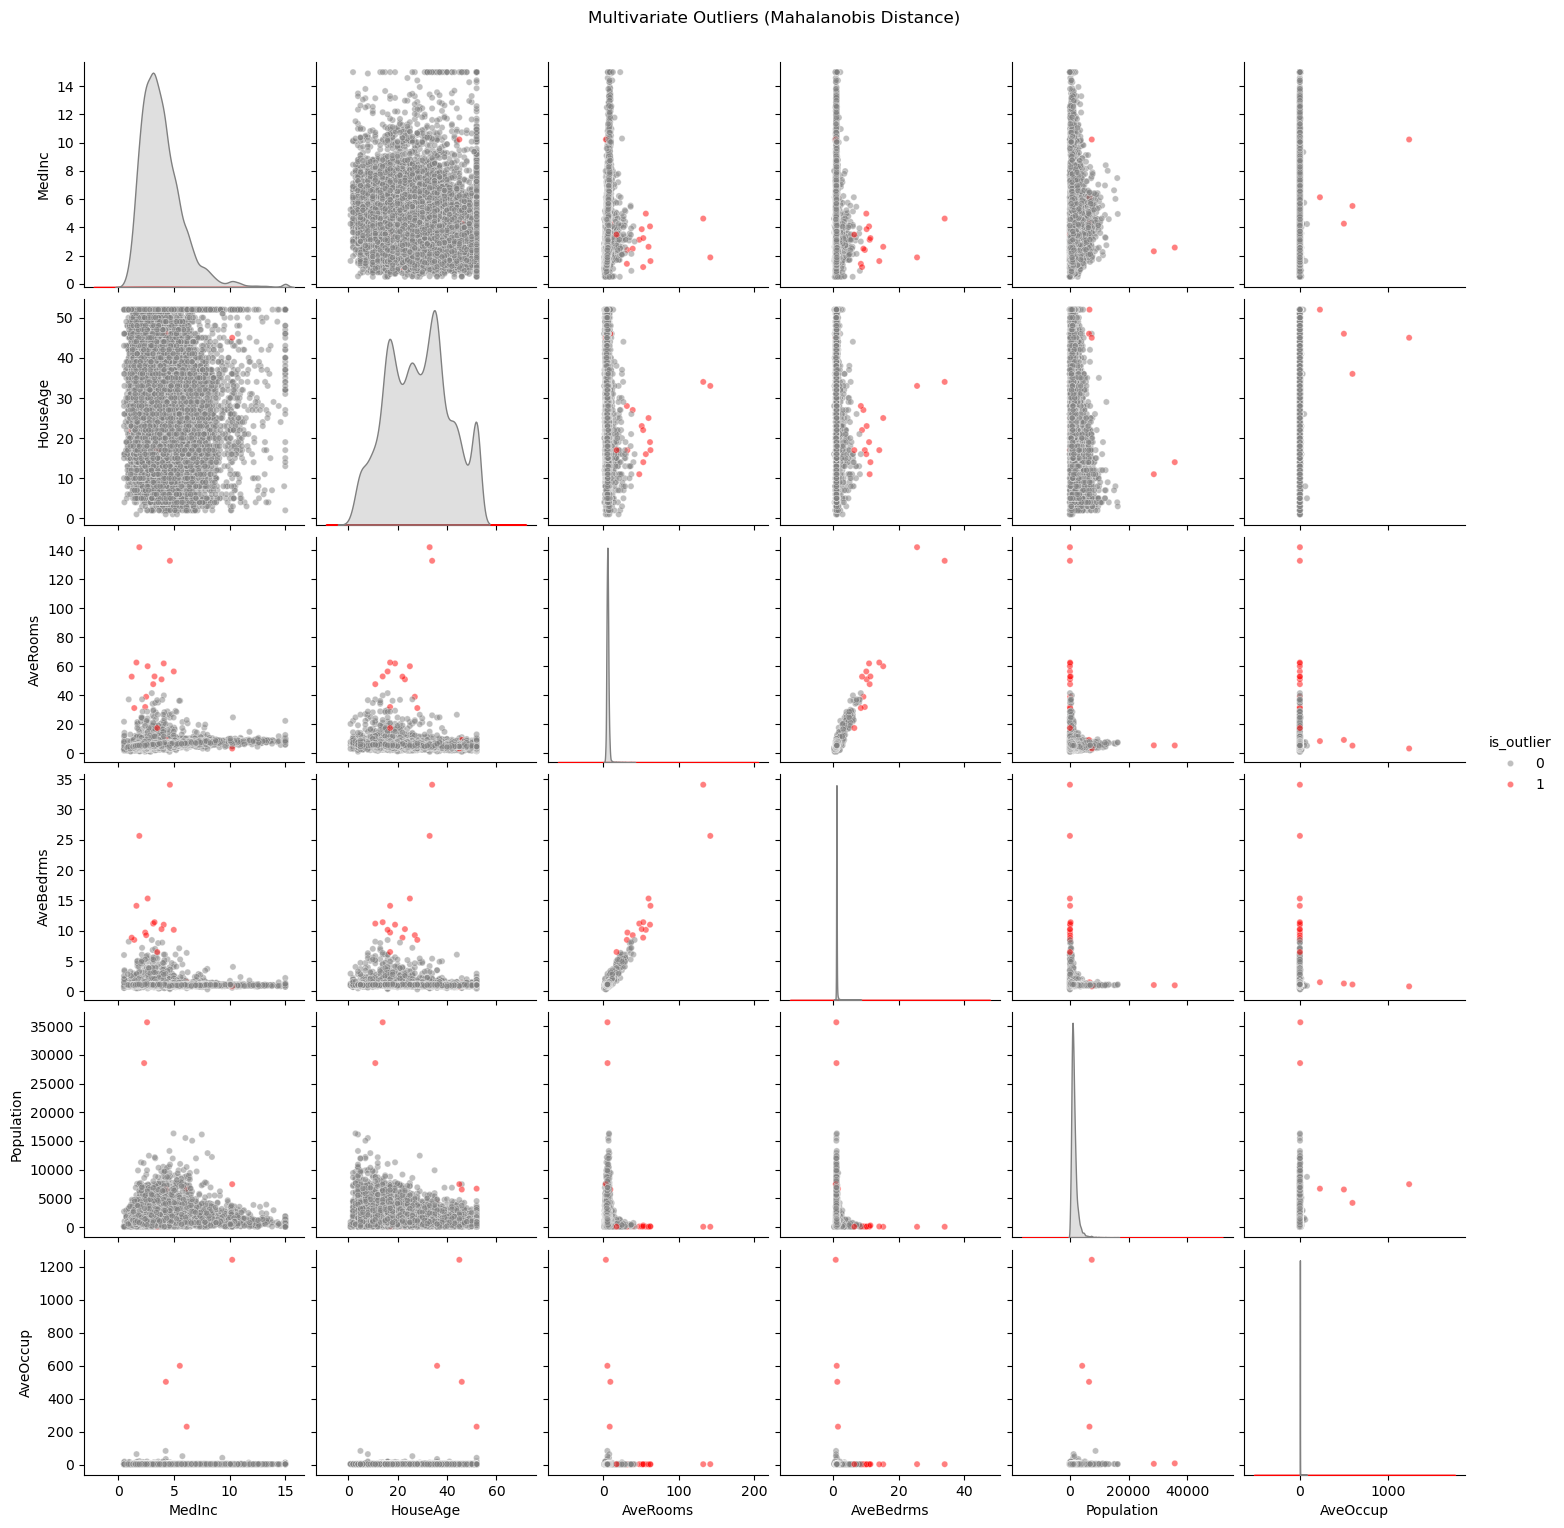

In [85]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

numeric_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
data_subset = df[numeric_cols]

mv_outliers = detect_multivariate_outliers(data_subset, threshold=0.99)

print(f"Multivariate outliers found: {len(mv_outliers)}")
print(f"Indices (first 10): {mv_outliers[:10]}")

df['is_outlier'] = 0
df.loc[mv_outliers, 'is_outlier'] = 1

sns.pairplot(df[numeric_cols + ['is_outlier']], hue='is_outlier',
             palette={0: 'gray', 1: 'red'}, plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Multivariate Outliers (Mahalanobis Distance)', y=1.02)
plt.show()